### Build Model and Train

In [1]:
# Imports
import os, sys
import torch
import numpy as np

if "__file__" in globals():
    script_dir = os.path.dirname(os.path.abspath(__file__))
else:
    script_dir = os.getcwd()

utils_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "Utils"))
model_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "src"))
output_dir = os.path.abspath(os.path.join(script_dir, "..", "Outputs"))

sys.path.append(utils_dir)
sys.path.append(model_dir)
from data_processing import load_cluster
from yaml_processor import load_config, save_config
from sensor_processing import sensor_processing

from EDM import EDM

config_file = os.path.abspath(os.path.join(script_dir, "..", "configuration.yaml"))
config_global = load_config(config_file)

##### Initialization

In [2]:
# Parameters
cluster = 0
chkpnt_path = os.path.join(output_dir, "model_checkpoint", str(cluster))
nt = config_global["data"]["nt"]
T = 1/np.pi
t = np.linspace(0, T, nt)
dt = t[1]-t[0]

In [3]:
# Set device
device = ('cuda:0' if torch.cuda.is_available() else 'cpu')
# Load Data
cluster = 0
FS_train, params_train, ft_train, disp_norm, vel_norm, ft_norm = load_cluster(os.path.join(output_dir, "datasets", "Train"), cluster, normalize=True)
FS_val, params_val, ft_val, _, _, _ = load_cluster(os.path.join(output_dir, "datasets", "Val"), cluster, True, disp_norm, vel_norm, ft_norm)
FS_test, params_test, ft_test, _, _, _ = load_cluster(os.path.join(output_dir, "datasets", "Test"), cluster, True, disp_norm, vel_norm, ft_norm)

In [7]:
# Apply Sensor Placement
sp = sensor_processing(FS_train[:, 1], config_global)
A_Mat, C_Mat, pinv_Theta, sensor_placement = sp.load(output_dir)
RS_train, RS_val, RS_test = sp.apply_sensors(FS_train, FS_val, FS_test)

# Reshape
n_dim = RS_train.shape[1]
RS_train = np.concatenate([RS_train[:, i, :, :] for i in range(n_dim)], axis=-1)
RS_val = np.concatenate([RS_val[:, i, :, :] for i in range(n_dim)], axis=-1)
RS_test = np.concatenate([RS_test[:, i, :, :] for i in range(n_dim)], axis=-1)

##### Import Model

In [8]:
model = EDM(A_Mat, pinv_Theta, dt, config_global, device)

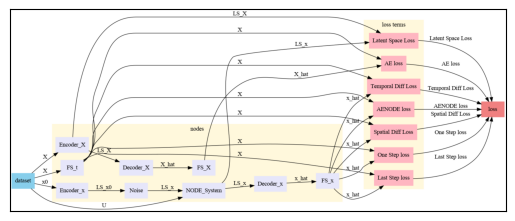

In [9]:
model.build_model()

In [10]:
problem = model.train_model(chkpnt_path, RS_train, ft_train, RS_val, ft_val, RS_test, ft_test)

None
Number of parameters: 137596

 Current Learning Rate - 0.01


/home/halsali/miniconda3/envs/neuromancer-gpu/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


epoch: 0	train_loss: 11.95216	eltime:  0.42764
epoch: 1	train_loss: 3.97183	eltime:  0.67033
epoch: 2	train_loss: 1.85520	eltime:  1.05319
epoch: 3	train_loss: 1.27796	eltime:  1.29303
epoch: 4	train_loss: 1.04506	eltime:  1.53205
epoch: 5	train_loss: 0.96659	eltime:  1.76973
epoch: 6	train_loss: 0.92156	eltime:  2.15878
epoch: 7	train_loss: 0.84958	eltime:  2.40152
epoch: 8	train_loss: 0.88108	eltime:  2.64273
epoch: 9	train_loss: 0.80121	eltime:  3.03670
epoch: 10	train_loss: 0.82267	eltime:  3.27237
epoch: 11	train_loss: 0.80702	eltime:  3.51023
epoch: 12	train_loss: 0.77554	eltime:  3.74562
epoch: 13	train_loss: 0.77149	eltime:  4.13368
epoch: 14	train_loss: 0.66108	eltime:  4.38845
epoch: 15	train_loss: 0.42659	eltime:  4.64748
epoch: 16	train_loss: 0.31669	eltime:  4.90127
epoch: 17	train_loss: 0.27814	eltime:  5.32636
epoch: 18	train_loss: 0.27653	eltime:  5.56457
epoch: 19	train_loss: 0.26615	eltime:  5.80116
epoch: 20	train_loss: 0.25173	eltime:  6.03772
epoch: 21	train_loss: 